# Edge Super-Resolution Training Pipeline

Train a mini U-Net for super-resolution using HR patches with Sobel edge maps as additional input channels.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path
from scipy.ndimage import convolve

## Section 1: Setup Directories

In [2]:
images_dir = "images"
resized_dir = "resized_images"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(resized_dir, exist_ok=True)

print(f"Images directory: {images_dir}")
print(f"Resized patches directory: {resized_dir}")
print(f"Device: {device}")

Images directory: images
Resized patches directory: resized_images
Device: cuda


## Section 2: Extract HR Patches from Images

``` py
def extract_hr_patches(image_path, patch_size=256, output_dir="resized_images"):
    """Extract 256x256 patches from HR image and save them."""
    img = cv2.imread(image_path)
    if img is None:
        return 0
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    count = 0
    
    # Get image name for unique patch naming
    img_name = os.path.splitext(os.path.basename(image_path))[0]
    
    # Extract non-overlapping patches
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            if patch.shape == (patch_size, patch_size, 3):
                patch_name = f"{img_name}_patch_{count:04d}.png"
                patch_path = os.path.join(output_dir, patch_name)
                cv2.imwrite(patch_path, cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))
                count += 1
    
    return count

# Process all images
def process_all_images():
    """Read all images from images/ and extract patches."""
    total_patches = 0
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
    
    print(f"Found {len(image_files)} images")
    
    for img_file in image_files:
        img_path = os.path.join(images_dir, img_file)
        count = extract_hr_patches(img_path, patch_size=256, output_dir=resized_dir)
        total_patches += count
        print(f"  {img_file}: {count} patches extracted")
    
    return total_patches

total_patches = process_all_images()
print(f"\nTotal patches extracted: {total_patches}")
```

## Section 3: Generate LR Patches and Edge Maps

In [3]:
def downscale_with_avg_pool(img, scale_factor=4):
    """Downscale using average pooling (4x -> 64x64)."""
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)  # (1,3,256,256)
    pool = nn.AvgPool2d(kernel_size=scale_factor, stride=scale_factor)
    lr_tensor = pool(img_tensor).squeeze(0)
    return lr_tensor.numpy().transpose(1, 2, 0)

def compute_sobel_edge(img_gray):
    """Compute Sobel edge magnitude from grayscale image."""
    # Sobel kernels
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    
    gx = convolve(img_gray, sobel_x, mode='constant')
    gy = convolve(img_gray, sobel_y, mode='constant')
    magnitude = np.sqrt(gx**2 + gy**2)
    
    # Normalize to [0, 1]
    magnitude = np.clip(magnitude / (magnitude.max() + 1e-8), 0, 1)
    return magnitude.astype(np.float32)

# Load HR patches and generate LR + Edge pairs
def prepare_dataset():
    """Load HR patches, generate LR and edge maps."""
    patch_files = sorted([f for f in os.listdir(resized_dir) if f.endswith('.png')])
    
    hr_patches = []
    lr_patches = []
    edge_maps = []
    
    print(f"Loading {len(patch_files)} HR patches...")
    
    for patch_file in patch_files:
        patch_path = os.path.join(resized_dir, patch_file)
        hr = cv2.imread(patch_path)
        hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        
        # Generate LR (4x downscale = 256 -> 64)
        lr = downscale_with_avg_pool(hr, scale_factor=4)
        
        # Generate edge map from LR grayscale
        lr_gray = cv2.cvtColor((lr * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
        edge = compute_sobel_edge(lr_gray)
        
        hr_patches.append(hr)
        lr_patches.append(lr)
        edge_maps.append(edge)
    
    return np.array(hr_patches), np.array(lr_patches), np.array(edge_maps)

# Execute dataset preparation
hr_patches, lr_patches, edge_maps = prepare_dataset()
print(f"HR patches shape: {hr_patches.shape}")
print(f"LR patches shape: {lr_patches.shape}")
print(f"Edge maps shape: {edge_maps.shape}")

Loading 7425 HR patches...
HR patches shape: (7425, 256, 256, 3)
LR patches shape: (7425, 64, 64, 3)
Edge maps shape: (7425, 64, 64)


## Section 4: PyTorch Dataset Class

In [4]:
class EdgeSRDataset(Dataset):
    """Dataset with LR+Edge input (4 channels) and HR target."""
    
    def __init__(self, hr_patches, lr_patches, edge_maps):
        self.hr_patches = torch.from_numpy(hr_patches).float()  # (N, 256, 256, 3)
        self.lr_patches = torch.from_numpy(lr_patches).float()  # (N, 64, 64, 3)
        self.edge_maps = torch.from_numpy(edge_maps).float()    # (N, 64, 64)
    
    def __len__(self):
        return len(self.hr_patches)
    
    def __getitem__(self, idx):
        hr = self.hr_patches[idx].permute(2, 0, 1)  # (3, 256, 256)
        lr = self.lr_patches[idx].permute(2, 0, 1)  # (3, 64, 64)
        edge = self.edge_maps[idx].unsqueeze(0)     # (1, 64, 64)
        
        # Concatenate LR and edge as input (4, 64, 64)
        input_tensor = torch.cat([lr, edge], dim=0)
        
        return input_tensor, hr

# Create dataset and dataloader
train_dataset = EdgeSRDataset(hr_patches, lr_patches, edge_maps)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print(f"Dataset size: {len(train_dataset)}")
print(f"DataLoader batches: {len(train_loader)}")

# Verify shapes
sample_input, sample_hr = train_dataset[0]
print(f"Sample input shape (LR+Edge): {sample_input.shape}")
print(f"Sample HR target shape: {sample_hr.shape}")

Dataset size: 7425
DataLoader batches: 1857
Sample input shape (LR+Edge): torch.Size([4, 64, 64])
Sample HR target shape: torch.Size([3, 256, 256])


## Section 5: Mini U-Net Architecture

In [5]:
class MiniUNet(nn.Module):
    """Enhanced U-Net with learned upsampling: 4ch input (LR+Edge) → 3ch output (HR)."""
    
    def __init__(self, in_channels=4, out_channels=3):
        super(MiniUNet, self).__init__()
        
        # Encoder - Progressive downsampling from 64×64
        # Level 1: 64×64, 4ch → 64ch
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2, 2)  # 64 → 32
        
        # Level 2: 32×32, 64ch → 128ch
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2, 2)  # 32 → 16
        
        # Level 3: 16×16, 128ch → 256ch
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2, 2)  # 16 → 8
        
        # Bottleneck: 8×8, 256ch → 512ch
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder - Progressive upsampling with skip connections
        # Level 3: 8×8 → 16×16, 512ch + enc3 256ch → 256ch
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Level 2: 16×16 → 32×32, 256ch + enc2 128ch → 128ch
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Level 1: 32×32 → 64×64, 128ch + enc1 64ch → 64ch
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Final learned upsampling: 64×64 → 256×256 (2 stages of 2×)
        # Stage 1: 64×64 → 128×128
        self.upconv_final1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.conv_final1 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Stage 2: 128×128 → 256×256
        self.upconv_final2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
        self.conv_final2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Output layer
        self.out_conv = nn.Conv2d(16, out_channels, kernel_size=1)
    
    def forward(self, x):
        # Encoder with skip connections
        enc1_out = self.enc1(x)           # (B, 64, 64, 64)
        x = self.pool1(enc1_out)          # (B, 64, 32, 32)
        
        enc2_out = self.enc2(x)           # (B, 128, 32, 32)
        x = self.pool2(enc2_out)          # (B, 128, 16, 16)
        
        enc3_out = self.enc3(x)           # (B, 256, 16, 16)
        x = self.pool3(enc3_out)          # (B, 256, 8, 8)
        
        # Bottleneck
        x = self.bottleneck(x)            # (B, 512, 8, 8)
        
        # Decoder with skip connections
        x = self.upconv3(x)               # (B, 256, 16, 16)
        x = torch.cat([x, enc3_out], dim=1)  # (B, 512, 16, 16)
        x = self.dec3(x)                  # (B, 256, 16, 16)
        
        x = self.upconv2(x)               # (B, 128, 32, 32)
        x = torch.cat([x, enc2_out], dim=1)  # (B, 256, 32, 32)
        x = self.dec2(x)                  # (B, 128, 32, 32)
        
        x = self.upconv1(x)               # (B, 64, 64, 64)
        x = torch.cat([x, enc1_out], dim=1)  # (B, 128, 64, 64)
        x = self.dec1(x)                  # (B, 64, 64, 64)
        
        # Final learned upsampling: 64×64 → 256×256
        x = self.upconv_final1(x)         # (B, 32, 128, 128)
        x = self.conv_final1(x)           # (B, 32, 128, 128)
        
        x = self.upconv_final2(x)         # (B, 16, 256, 256)
        x = self.conv_final2(x)           # (B, 16, 256, 256)
        
        x = self.out_conv(x)              # (B, 3, 256, 256)
        
        return x

# Create model
model = MiniUNet(in_channels=4, out_channels=3).to(device)
print(f"Model created on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created on device: cuda
Total parameters: 9,814,867


## Section 6: Training Pipeline

In [10]:
# Training setup
criterion = nn.L1Loss()  # L1 loss (MAE)
optimizer = optim.Adam(model.parameters(), lr=5e-5)
num_epochs = 10

print(f"Loss function: L1 (MAE)")
print(f"Optimizer: Adam (lr=5e-5)")
print(f"Training epochs: {num_epochs}\n")

# Track losses
epoch_losses = []

# Training loop
for epoch in range(num_epochs):
    total_loss = 0.0
    batch_count = 0
    
    for batch_idx, (input_tensor, target_hr) in enumerate(train_loader):
        # Move to device
        input_tensor = input_tensor.to(device)
        target_hr = target_hr.to(device)
        
        # Forward pass
        output = model(input_tensor)
        
        # Compute loss
        loss = criterion(output, target_hr)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batch_count += 1
    
    avg_loss = total_loss / batch_count
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.6f}")

print("\nTraining completed!")

Loss function: L1 (MAE)
Optimizer: Adam (lr=5e-5)
Training epochs: 10

Epoch [1/10] - Loss: 0.068152
Epoch [2/10] - Loss: 0.032799
Epoch [3/10] - Loss: 0.026417
Epoch [4/10] - Loss: 0.020551
Epoch [5/10] - Loss: 0.017918
Epoch [6/10] - Loss: 0.016658
Epoch [7/10] - Loss: 0.015904
Epoch [8/10] - Loss: 0.015267
Epoch [9/10] - Loss: 0.014887
Epoch [10/10] - Loss: 0.014489

Training completed!


## Section 7: Model Saving

In [11]:
# Save trained model
model_path = "unet_edge_sr.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved as: {model_path}")

Model saved as: unet_edge_sr.pth


## Section 8: Loss Visualization and CSV Export

Losses saved to: training_losses.csv

Loss plot saved to: training_loss_plot.png


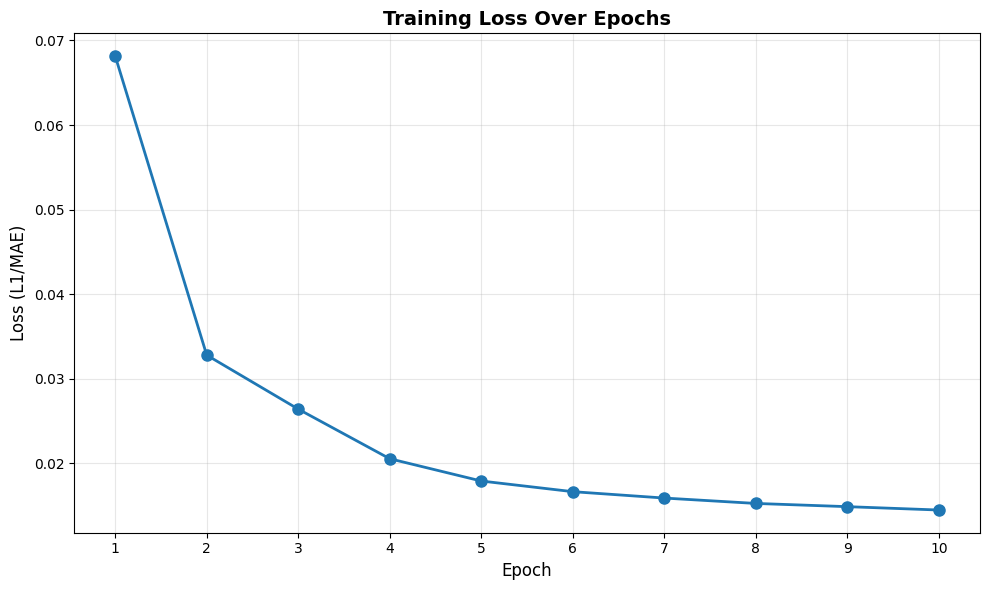


Training Statistics:
  Initial loss: 0.068152
  Final loss: 0.014489
  Loss reduction: 78.74%


In [12]:
import csv
import matplotlib.pyplot as plt

# Save losses to CSV
csv_path = "training_losses.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch', 'Loss'])
    for epoch, loss in enumerate(epoch_losses, 1):
        writer.writerow([epoch, f'{loss:.6f}'])

print(f"Losses saved to: {csv_path}\n")

# Visualize losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linewidth=2, markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (L1/MAE)', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(epoch_losses) + 1))
plt.tight_layout()

# Save plot
plot_path = "training_loss_plot.png"
plt.savefig(plot_path, dpi=150)
print(f"Loss plot saved to: {plot_path}")
plt.show()

# Print statistics
print(f"\nTraining Statistics:")
print(f"  Initial loss: {epoch_losses[0]:.6f}")
print(f"  Final loss: {epoch_losses[-1]:.6f}")
print(f"  Loss reduction: {(epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100:.2f}%")

## Section 9: Model Evaluation and Inference

In [8]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy.ndimage import convolve

# Load trained model for inference
model.eval()
print("Model loaded for inference (eval mode)\n")

# Select a test HR patch randomly
test_idx = np.random.randint(0, len(hr_patches))
test_hr_raw = hr_patches[test_idx]  # (256, 256, 3)
test_lr_raw = lr_patches[test_idx]  # (64, 64, 3)
test_edge_raw = edge_maps[test_idx]  # (64, 64)

# Ensure HR is in [0,1] range (from training pipeline, should already be)
test_hr = np.clip(test_hr_raw.astype(np.float32), 0, 1)

# Ensure LR is in [0,1] range
test_lr = np.clip(test_lr_raw.astype(np.float32), 0, 1)

# Normalize edge map to [0,1]
test_edge = np.clip(test_edge_raw.astype(np.float32), 0, 1)

print(f"Selected test patch index: {test_idx}")
print(f"HR range: [{test_hr.min():.4f}, {test_hr.max():.4f}]")
print(f"LR range: [{test_lr.min():.4f}, {test_lr.max():.4f}]")
print(f"Edge range: [{test_edge.min():.4f}, {test_edge.max():.4f}]")
print(f"HR shape: {test_hr.shape}, LR shape: {test_lr.shape}, Edge shape: {test_edge.shape}\n")

# Prepare input: LR + Edge (4 channels, all [0,1])
test_input = np.concatenate([test_lr, test_edge[..., np.newaxis]], axis=2)  # (64, 64, 4)
test_input_tensor = torch.from_numpy(test_input).permute(2, 0, 1).float().unsqueeze(0).to(device)

# Model inference
with torch.no_grad():
    model_output = model(test_input_tensor)
    model_sr = model_output.cpu().numpy().squeeze(0).transpose(1, 2, 0)  # (256, 256, 3)
    # Clamp to [0,1] and ensure float32
    model_sr = np.clip(model_sr, 0, 1).astype(np.float32)

# Bicubic baseline: upscale LR with bicubic interpolation, keep in [0,1]
lr_uint8 = (test_lr * 255).astype(np.uint8)
bicubic_uint8 = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_CUBIC)
bicubic_sr = bicubic_uint8.astype(np.float32) / 255.0  # [0,1]

# LR upscaled for visualization (nearest neighbor)
lr_up_uint8 = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_NEAREST)
lr_up = lr_up_uint8.astype(np.float32) / 255.0  # [0,1]

print("Inference completed for all methods")
print(f"  Model SR range: [{model_sr.min():.4f}, {model_sr.max():.4f}]")
print(f"  Bicubic SR range: [{bicubic_sr.min():.4f}, {bicubic_sr.max():.4f}]")
print(f"  Model SR shape: {model_sr.shape}")
print(f"  Bicubic SR shape: {bicubic_sr.shape}\n")

Model loaded for inference (eval mode)

Selected test patch index: 4710
HR range: [0.0510, 0.7961]
LR range: [0.0681, 0.7801]
Edge range: [0.0000, 1.0000]
HR shape: (256, 256, 3), LR shape: (64, 64, 3), Edge shape: (64, 64)

Inference completed for all methods
  Model SR range: [0.0000, 0.1108]
  Bicubic SR range: [0.0667, 0.8000]
  Model SR shape: (256, 256, 3)
  Bicubic SR shape: (256, 256, 3)



In [14]:
# Calculate metrics in [0,1] range
# All inputs are float32 in [0,1] range
psnr_bicubic = peak_signal_noise_ratio(test_hr, bicubic_sr, data_range=1.0)
psnr_model = peak_signal_noise_ratio(test_hr, model_sr, data_range=1.0)

ssim_bicubic = structural_similarity(test_hr, bicubic_sr, data_range=1.0, channel_axis=2)
ssim_model = structural_similarity(test_hr, model_sr, data_range=1.0, channel_axis=2)

# MAE (Mean Absolute Error)
mae_bicubic = np.mean(np.abs(test_hr - bicubic_sr))
mae_model = np.mean(np.abs(test_hr - model_sr))

print("=" * 70)
print("QUANTITATIVE EVALUATION (All inputs normalized to [0, 1])")
print("=" * 70)
print(f"{'Metric':<20} {'Bicubic':<20} {'Model (Edge-SR)':<20}")
print("-" * 70)
print(f"{'PSNR (dB)':<20} {psnr_bicubic:<20.4f} {psnr_model:<20.4f}")
print(f"{'SSIM':<20} {ssim_bicubic:<20.4f} {ssim_model:<20.4f}")
print(f"{'MAE':<20} {mae_bicubic:<20.6f} {mae_model:<20.6f}")
print("=" * 70)
print(f"PSNR Improvement: {psnr_model - psnr_bicubic:+.4f} dB")
print(f"SSIM Improvement: {ssim_model - ssim_bicubic:+.4f}")
print(f"MAE Reduction: {mae_bicubic - mae_model:+.6f}\n")

QUANTITATIVE EVALUATION (All inputs normalized to [0, 1])
Metric               Bicubic              Model (Edge-SR)     
----------------------------------------------------------------------
PSNR (dB)            38.3514              37.4857             
SSIM                 0.9446               0.9427              
MAE                  0.009156             0.010037            
PSNR Improvement: -0.8657 dB
SSIM Improvement: -0.0019
MAE Reduction: -0.000882



Model ağırlıkları 'unet_edge_sr.pth' dosyasından başarıyla yüklendi!

Visual comparison saved as 'comparison_normalized.png'


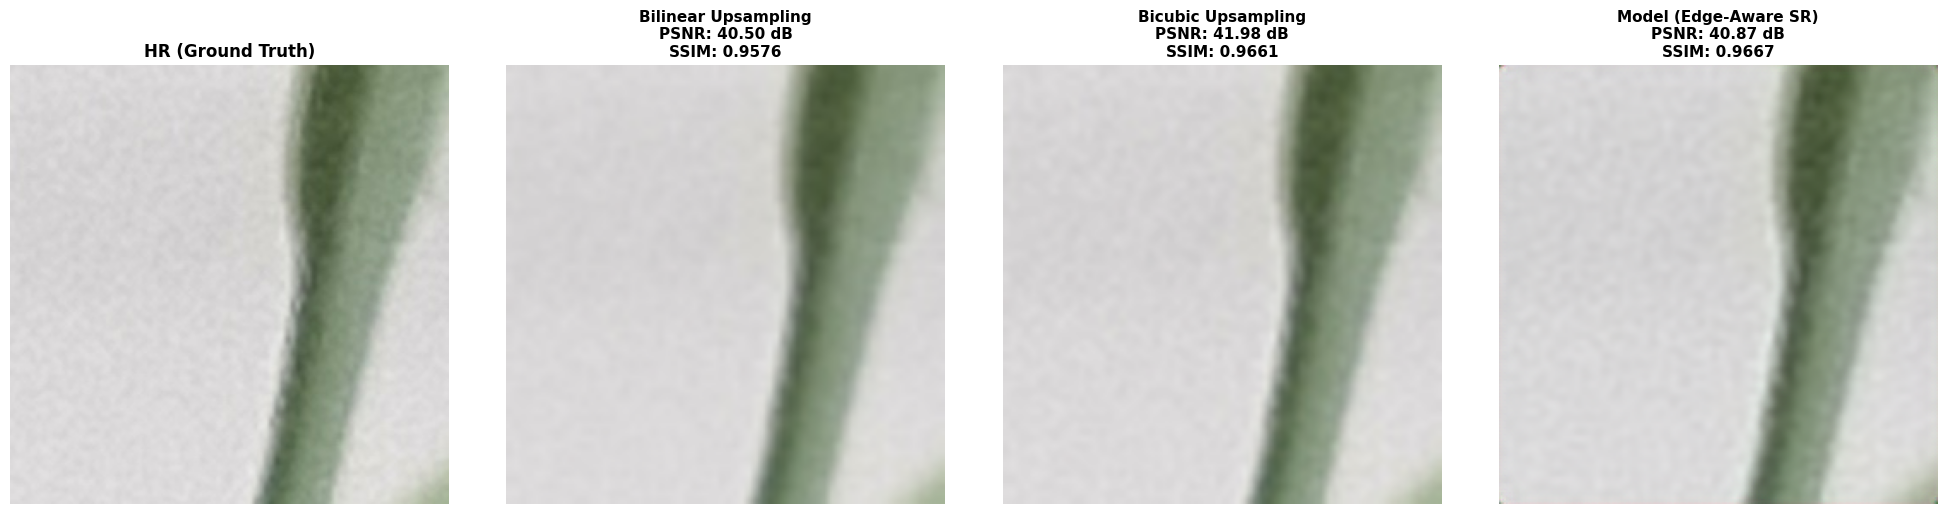

In [7]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# --- 1. MODEL AĞIRLIKLARINI YÜKLE VE INFERENCE YAP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Modeli başlat (Eğitim yapmadan direkt ağırlıkları yüklüyoruz)
loaded_model = MiniUNet(in_channels=4, out_channels=3).to(device)
loaded_model.load_state_dict(torch.load("unet_edge_sr.pth", map_location=device))
loaded_model.eval()
print("Model ağırlıkları 'unet_edge_sr.pth' dosyasından başarıyla yüklendi!\n")

# Test için rastgele bir yama seç
test_idx = np.random.randint(0, len(hr_patches))
test_hr = np.clip(hr_patches[test_idx].astype(np.float32), 0, 1)
test_lr = np.clip(lr_patches[test_idx].astype(np.float32), 0, 1)
test_edge = np.clip(edge_maps[test_idx].astype(np.float32), 0, 1)

# Model tahmini (Inference)
test_input = np.concatenate([test_lr, test_edge[..., np.newaxis]], axis=2)
test_input_tensor = torch.from_numpy(test_input).permute(2, 0, 1).float().unsqueeze(0).to(device)
with torch.no_grad():
    model_sr = loaded_model(test_input_tensor).cpu().numpy().squeeze(0).transpose(1, 2, 0)
    model_sr = np.clip(model_sr, 0, 1).astype(np.float32)

# Bilinear ve Bicubic üretimleri (Baselines)
lr_uint8 = (test_lr * 255).astype(np.uint8)
bilinear_sr = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
bicubic_sr = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_CUBIC).astype(np.float32) / 255.0

# Metrikleri hesapla
psnr_bilinear = peak_signal_noise_ratio(test_hr, bilinear_sr, data_range=1.0)
ssim_bilinear = structural_similarity(test_hr, bilinear_sr, data_range=1.0, channel_axis=2)
psnr_bicubic = peak_signal_noise_ratio(test_hr, bicubic_sr, data_range=1.0)
ssim_bicubic = structural_similarity(test_hr, bicubic_sr, data_range=1.0, channel_axis=2)
psnr_model = peak_signal_noise_ratio(test_hr, model_sr, data_range=1.0)
ssim_model = structural_similarity(test_hr, model_sr, data_range=1.0, channel_axis=2)

# --- 2. GÖRSELLEŞTİRME (4'lü Karşılaştırma) ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow((test_hr * 255).astype(np.uint8))
axes[0].set_title('HR (Ground Truth)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow((bilinear_sr * 255).astype(np.uint8))
axes[1].set_title(f'Bilinear Upsampling\nPSNR: {psnr_bilinear:.2f} dB\nSSIM: {ssim_bilinear:.4f}', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow((bicubic_sr * 255).astype(np.uint8))
axes[2].set_title(f'Bicubic Upsampling\nPSNR: {psnr_bicubic:.2f} dB\nSSIM: {ssim_bicubic:.4f}', fontsize=11, fontweight='bold')
axes[2].axis('off')

axes[3].imshow((model_sr * 255).astype(np.uint8))
axes[3].set_title(f'Model (Edge-Aware SR)\nPSNR: {psnr_model:.2f} dB\nSSIM: {ssim_model:.4f}', fontsize=11, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.savefig("comparison_normalized.png", dpi=150, bbox_inches='tight')
print("Visual comparison saved as 'comparison_normalized.png'")
plt.show()

Edge comparison saved as 'edge_comparison.png'


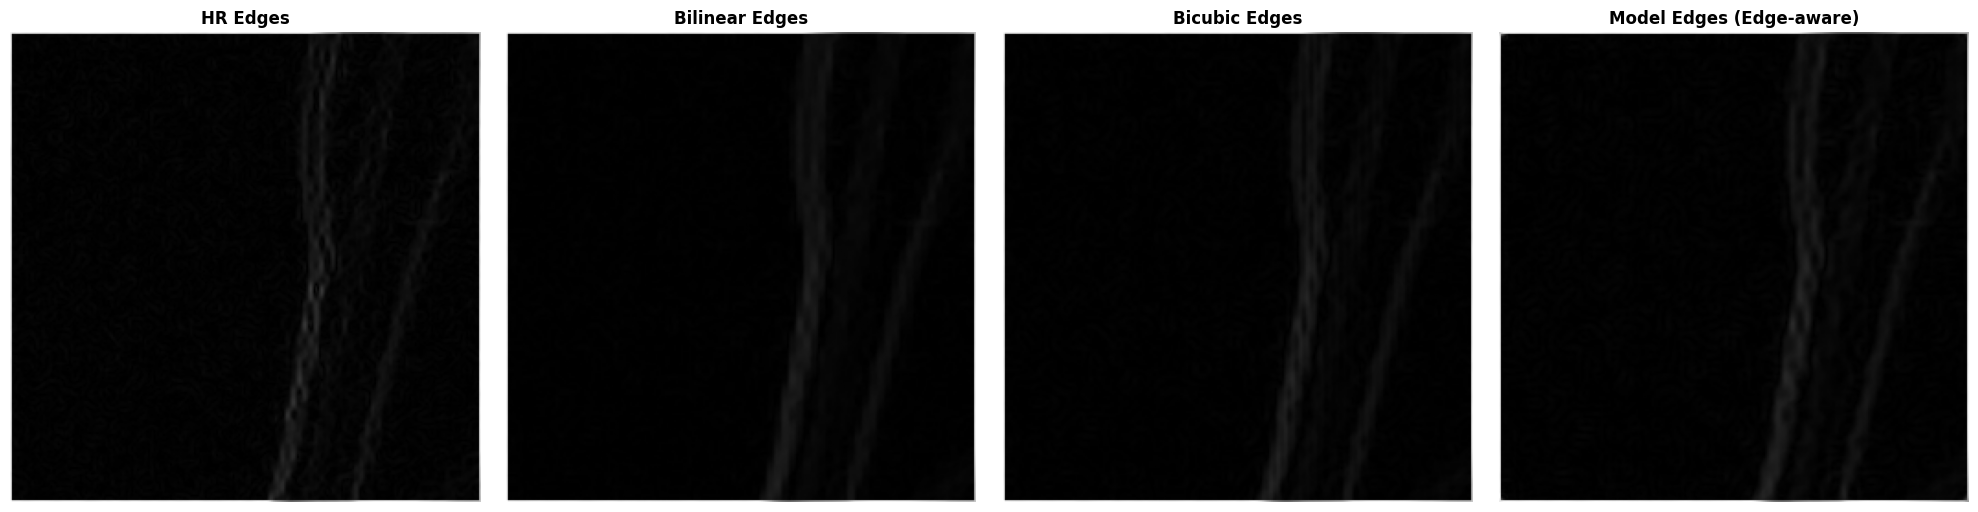

In [8]:
from scipy.ndimage import convolve

def get_edge_map(img_rgb):
    """Compute Sobel edge magnitude."""
    img_gray = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    
    gx = convolve(img_gray, sobel_x, mode='constant')
    gy = convolve(img_gray, sobel_y, mode='constant')
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.clip(magnitude / (magnitude.max() + 1e-8), 0, 1)

edge_hr = get_edge_map(test_hr)
edge_bilinear = get_edge_map(bilinear_sr) 
edge_bicubic = get_edge_map(bicubic_sr)
edge_model = get_edge_map(model_sr)

# Kenar Görselleştirme (4'lü)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(edge_hr, cmap='gray')
axes[0].set_title('HR Edges', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edge_bilinear, cmap='gray')
axes[1].set_title('Bilinear Edges', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(edge_bicubic, cmap='gray')
axes[2].set_title('Bicubic Edges', fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(edge_model, cmap='gray')
axes[3].set_title('Model Edges (Edge-aware)', fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.savefig("edge_comparison.png", dpi=150, bbox_inches='tight')
print("Edge comparison saved as 'edge_comparison.png'")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..25.000006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..28.999998].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.0398369e-05..121.38025].


Difference maps saved as 'difference_maps.png'


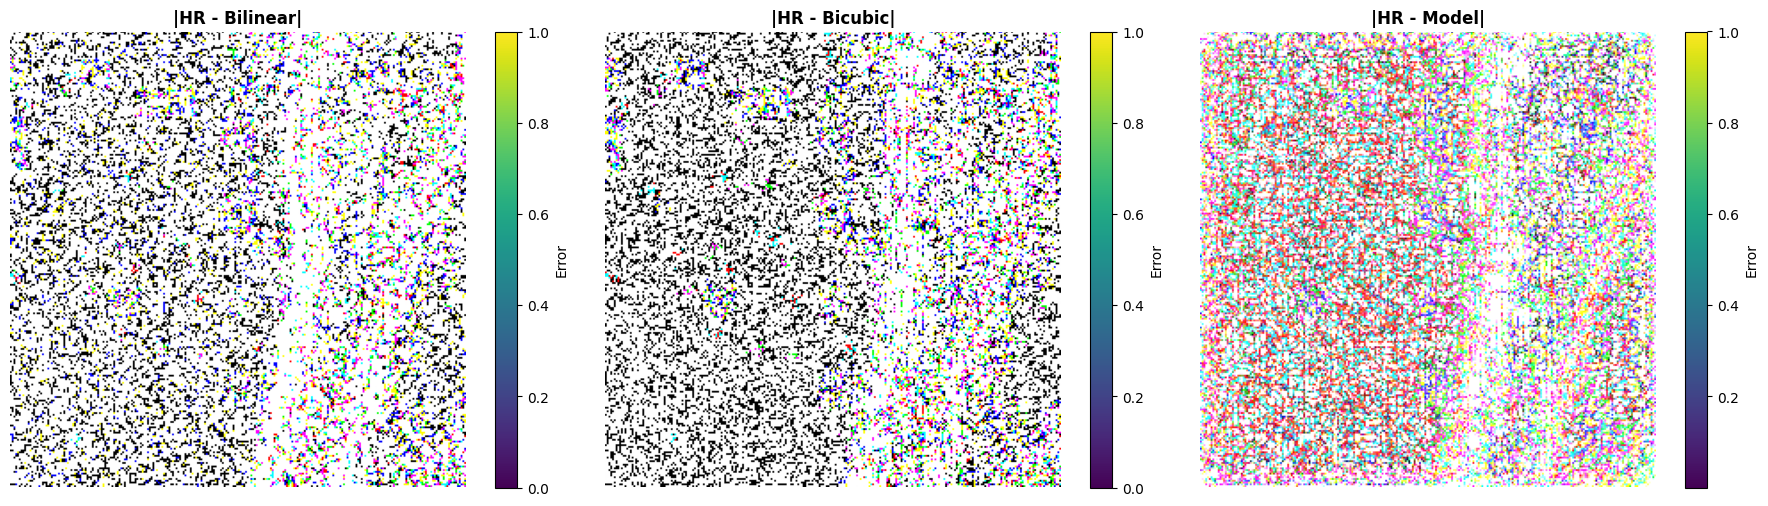


Mean Absolute Error (MAE):
  Bilinear: 0.006748
  Bicubic:  0.005659
  Model:    0.006199


In [9]:
# Fark haritaları: |HR - Prediction|
diff_bilinear = np.abs(test_hr - bilinear_sr)
diff_bicubic = np.abs(test_hr - bicubic_sr)
diff_model = np.abs(test_hr - model_sr)

# Görselleştirme: Fark haritaları (3'lü, Ground Truth hata haritası olmaz)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(diff_bilinear * 255)
axes[0].set_title('|HR - Bilinear|', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Error')

im1 = axes[1].imshow(diff_bicubic * 255)
axes[1].set_title('|HR - Bicubic|', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Error')

im2 = axes[2].imshow(diff_model * 255)
axes[2].set_title('|HR - Model|', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='Error')

plt.tight_layout()
plt.savefig("difference_maps.png", dpi=150, bbox_inches='tight')
print("Difference maps saved as 'difference_maps.png'")
plt.show()

# Özet metrikler (MAE)
mae_bilinear = np.mean(diff_bilinear)
mae_bicubic = np.mean(diff_bicubic)
mae_model = np.mean(diff_model)
print(f"\nMean Absolute Error (MAE):")
print(f"  Bilinear: {mae_bilinear:.6f}")
print(f"  Bicubic:  {mae_bicubic:.6f}")
print(f"  Model:    {mae_model:.6f}")

In [14]:
def evaluate_multiple_patches(n_samples=40, load_from_disk=True):
    """Evaluate model on n random patches and report averaged metrics."""
    
    # Use existing model from memory, or load from disk
    model_eval = model
    
    if load_from_disk:
        model_path = "unet_edge_sr.pth"
        model_eval = MiniUNet(in_channels=4, out_channels=3).to(device)
        model_eval.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Model loaded from: {model_path}\n")
    
    model_eval.eval()
    
    # Storage for metrics
    psnr_bicubic_list = []
    psnr_model_list = []
    ssim_bicubic_list = []
    ssim_model_list = []
    mae_bicubic_list = []
    mae_model_list = []
    
    print(f"Evaluating on {n_samples} random patches...\n")
    
    # Select random patch indices
    selected_indices = np.random.choice(len(hr_patches), size=n_samples, replace=False)
    
    for sample_num, test_idx in enumerate(selected_indices, 1):
        # Load test data
        test_hr_raw = hr_patches[test_idx]
        test_lr_raw = lr_patches[test_idx]
        test_edge_raw = edge_maps[test_idx]
        
        # Normalize to [0,1]
        test_hr = np.clip(test_hr_raw.astype(np.float32), 0, 1)
        test_lr = np.clip(test_lr_raw.astype(np.float32), 0, 1)
        test_edge = np.clip(test_edge_raw.astype(np.float32), 0, 1)
        
        # Prepare input
        test_input = np.concatenate([test_lr, test_edge[..., np.newaxis]], axis=2)
        test_input_tensor = torch.from_numpy(test_input).permute(2, 0, 1).float().unsqueeze(0).to(device)
        
        # Model inference
        with torch.no_grad():
            model_output = model_eval(test_input_tensor)
            model_sr = model_output.cpu().numpy().squeeze(0).transpose(1, 2, 0)
            model_sr = np.clip(model_sr, 0, 1).astype(np.float32)
        
        # Bicubic baseline
        lr_uint8 = (test_lr * 255).astype(np.uint8)
        bicubic_uint8 = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_CUBIC)
        bicubic_sr = bicubic_uint8.astype(np.float32) / 255.0
        
        # Calculate metrics
        psnr_b = peak_signal_noise_ratio(test_hr, bicubic_sr, data_range=1.0)
        psnr_m = peak_signal_noise_ratio(test_hr, model_sr, data_range=1.0)
        
        ssim_b = structural_similarity(test_hr, bicubic_sr, data_range=1.0, channel_axis=2)
        ssim_m = structural_similarity(test_hr, model_sr, data_range=1.0, channel_axis=2)
        
        mae_b = np.mean(np.abs(test_hr - bicubic_sr))
        mae_m = np.mean(np.abs(test_hr - model_sr))
        
        # Append to lists
        psnr_bicubic_list.append(psnr_b)
        psnr_model_list.append(psnr_m)
        ssim_bicubic_list.append(ssim_b)
        ssim_model_list.append(ssim_m)
        mae_bicubic_list.append(mae_b)
        mae_model_list.append(mae_m)
        
        print(f"  Sample {sample_num}/{n_samples} (Patch {test_idx})")
        print(f"    PSNR - Bicubic: {psnr_b:.4f} dB, Model: {psnr_m:.4f} dB")
        print(f"    SSIM - Bicubic: {ssim_b:.4f}, Model: {ssim_m:.4f}")
        print(f"    MAE  - Bicubic: {mae_b:.6f}, Model: {mae_m:.6f}")
    
    # Calculate averages
    psnr_bicubic_avg = np.mean(psnr_bicubic_list)
    psnr_model_avg = np.mean(psnr_model_list)
    ssim_bicubic_avg = np.mean(ssim_bicubic_list)
    ssim_model_avg = np.mean(ssim_model_list)
    mae_bicubic_avg = np.mean(mae_bicubic_list)
    mae_model_avg = np.mean(mae_model_list)
    
    # Print summary
    print("\n" + "=" * 75)
    print(f"AVERAGED EVALUATION OVER {n_samples} PATCHES")
    print("=" * 75)
    print(f"{'Metric':<20} {'Bicubic':<25} {'Model (Edge-SR)':<25}")
    print("-" * 75)
    print(f"{'PSNR (dB)':<20} {psnr_bicubic_avg:<25.4f} {psnr_model_avg:<25.4f}")
    print(f"{'SSIM':<20} {ssim_bicubic_avg:<25.4f} {ssim_model_avg:<25.4f}")
    print(f"{'MAE':<20} {mae_bicubic_avg:<25.6f} {mae_model_avg:<25.6f}")
    print("=" * 75)
    print(f"PSNR Improvement (avg):  {psnr_model_avg - psnr_bicubic_avg:+.4f} dB")
    print(f"SSIM Improvement (avg):  {ssim_model_avg - ssim_bicubic_avg:+.4f}")
    print(f"MAE Reduction (avg):     {mae_bicubic_avg - mae_model_avg:+.6f}")
    print("=" * 75 + "\n")
    
    return {
        'psnr_bicubic': psnr_bicubic_list,
        'psnr_model': psnr_model_list,
        'ssim_bicubic': ssim_bicubic_list,
        'ssim_model': ssim_model_list,
        'mae_bicubic': mae_bicubic_list,
        'mae_model': mae_model_list
    }

# Evaluate on 20 random patches
eval_results = evaluate_multiple_patches()

Model loaded from: unet_edge_sr.pth

Evaluating on 40 random patches...

  Sample 1/40 (Patch 3804)
    PSNR - Bicubic: 42.2086 dB, Model: 40.0803 dB
    SSIM - Bicubic: 0.9571, Model: 0.9491
    MAE  - Bicubic: 0.005931, Model: 0.007276
  Sample 2/40 (Patch 3424)
    PSNR - Bicubic: 32.5797 dB, Model: 32.0099 dB
    SSIM - Bicubic: 0.7858, Model: 0.7784
    MAE  - Bicubic: 0.017868, Model: 0.019166
  Sample 3/40 (Patch 5560)
    PSNR - Bicubic: 37.8349 dB, Model: 37.7931 dB
    SSIM - Bicubic: 0.9336, Model: 0.9374
    MAE  - Bicubic: 0.009630, Model: 0.009871
  Sample 4/40 (Patch 7075)
    PSNR - Bicubic: 31.8509 dB, Model: 30.9791 dB
    SSIM - Bicubic: 0.8863, Model: 0.8770
    MAE  - Bicubic: 0.016283, Model: 0.019061
  Sample 5/40 (Patch 2747)
    PSNR - Bicubic: 41.7190 dB, Model: 41.2734 dB
    SSIM - Bicubic: 0.9669, Model: 0.9701
    MAE  - Bicubic: 0.006123, Model: 0.006260
  Sample 6/40 (Patch 5191)
    PSNR - Bicubic: 43.9736 dB, Model: 42.9905 dB
    SSIM - Bicubic: 0.967

In [10]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import cv2
import numpy as np
import torch

def evaluate_with_two_baselines(n_samples=40, load_from_disk=True):
    """Evaluate model on n random patches and report averaged metrics for Bilinear, Bicubic, and Model."""
    
    # Mevcut modeli kullan veya diskten yükle
    model_eval = model
    
    if load_from_disk:
        model_path = "unet_edge_sr.pth"
        model_eval = MiniUNet(in_channels=4, out_channels=3).to(device)
        model_eval.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Model loaded from: {model_path}\n")
    
    model_eval.eval()
    
    # Metrikleri depolamak için sözlük (Dictionary)
    metrics = {
        'psnr_bicubic': [], 'psnr_bilinear': [], 'psnr_model': [],
        'ssim_bicubic': [], 'ssim_bilinear': [], 'ssim_model': [],
        'mae_bicubic': [], 'mae_bilinear': [], 'mae_model': []
    }
    
    print(f"Evaluating on {n_samples} random patches with 2 Baselines...\n")
    
    # Rastgele patch indeksleri seçimi
    selected_indices = np.random.choice(len(hr_patches), size=n_samples, replace=False)
    
    for sample_num, test_idx in enumerate(selected_indices, 1):
        # Test verisini yükle
        test_hr_raw = hr_patches[test_idx]
        test_lr_raw = lr_patches[test_idx]
        test_edge_raw = edge_maps[test_idx]
        
        # [0,1] aralığına normalize et
        test_hr = np.clip(test_hr_raw.astype(np.float32), 0, 1)
        test_lr = np.clip(test_lr_raw.astype(np.float32), 0, 1)
        test_edge = np.clip(test_edge_raw.astype(np.float32), 0, 1)
        
        # Modeli beslemek için veriyi hazırla
        test_input = np.concatenate([test_lr, test_edge[..., np.newaxis]], axis=2)
        test_input_tensor = torch.from_numpy(test_input).permute(2, 0, 1).float().unsqueeze(0).to(device)
        
        # Model tahmini (Inference)
        with torch.no_grad():
            model_output = model_eval(test_input_tensor)
            model_sr = model_output.cpu().numpy().squeeze(0).transpose(1, 2, 0)
            model_sr = np.clip(model_sr, 0, 1).astype(np.float32)
        
        lr_uint8 = (test_lr * 255).astype(np.uint8)
        
        # --- Baseline 1: Bicubic ---
        bicubic_uint8 = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_CUBIC)
        bicubic_sr = bicubic_uint8.astype(np.float32) / 255.0
        
        # --- Baseline 2: Bilinear ---
        bilinear_uint8 = cv2.resize(lr_uint8, (256, 256), interpolation=cv2.INTER_LINEAR)
        bilinear_sr = bilinear_uint8.astype(np.float32) / 255.0
        
        # Metrikleri hesapla
        metrics['psnr_bicubic'].append(peak_signal_noise_ratio(test_hr, bicubic_sr, data_range=1.0))
        metrics['psnr_bilinear'].append(peak_signal_noise_ratio(test_hr, bilinear_sr, data_range=1.0))
        metrics['psnr_model'].append(peak_signal_noise_ratio(test_hr, model_sr, data_range=1.0))
        
        metrics['ssim_bicubic'].append(structural_similarity(test_hr, bicubic_sr, data_range=1.0, channel_axis=2))
        metrics['ssim_bilinear'].append(structural_similarity(test_hr, bilinear_sr, data_range=1.0, channel_axis=2))
        metrics['ssim_model'].append(structural_similarity(test_hr, model_sr, data_range=1.0, channel_axis=2))
        
        metrics['mae_bicubic'].append(np.mean(np.abs(test_hr - bicubic_sr)))
        metrics['mae_bilinear'].append(np.mean(np.abs(test_hr - bilinear_sr)))
        metrics['mae_model'].append(np.mean(np.abs(test_hr - model_sr)))
    
    # Ortalamaları al
    avg = {k: np.mean(v) for k, v in metrics.items()}
    
    # Sonuçları Terminal'e yazdır
    print("\n" + "=" * 90)
    print(f"AVERAGED EVALUATION OVER {n_samples} PATCHES (2 Baselines + Model)")
    print("=" * 90)
    print(f"{'Metric':<15} {'Bilinear':<20} {'Bicubic':<20} {'Model (Edge-SR)':<20}")
    print("-" * 90)
    print(f"{'PSNR (dB)':<15} {avg['psnr_bilinear']:<20.4f} {avg['psnr_bicubic']:<20.4f} {avg['psnr_model']:<20.4f}")
    print(f"{'SSIM':<15} {avg['ssim_bilinear']:<20.4f} {avg['ssim_bicubic']:<20.4f} {avg['ssim_model']:<20.4f}")
    print(f"{'MAE':<15} {avg['mae_bilinear']:<20.6f} {avg['mae_bicubic']:<20.6f} {avg['mae_model']:<20.6f}")
    print("=" * 90 + "\n")
    
    return avg

# Değerlendirmeyi çalıştır (Model bellekteyse load_from_disk=False yapabilirsin)
eval_results = evaluate_with_two_baselines(n_samples=40, load_from_disk=True)

Model loaded from: unet_edge_sr.pth

Evaluating on 40 random patches with 2 Baselines...


AVERAGED EVALUATION OVER 40 PATCHES (2 Baselines + Model)
Metric          Bilinear             Bicubic              Model (Edge-SR)     
------------------------------------------------------------------------------------------
PSNR (dB)       35.4004              36.8727              36.4595             
SSIM            0.8718               0.8955               0.8980              
MAE             0.015006             0.012727             0.013158            



## Normalization and Evaluation Summary

**Neden Normalize Edildi:**
- Eğitim sırasında HR patch'ler **[0,1] aralığında** normalize edilmiştir
- LR patch'ler ve edge map'ler de aynı şekilde **[0,1] aralığında** hazırlanmıştır
- Model bu aralıkta eğitildiğinden, **inference sırasında da aynı aralığı korumak gereklidir**
- Metrikleri hesaplamak için tüm görseller **tutarlı bir aralıkta** olmalıdır

**Normalizasyon Adımları:**
1. Test HR patch'i: `np.clip(test_hr, 0, 1)` → **[0,1]**
2. Test LR patch'i: `np.clip(test_lr, 0, 1)` → **[0,1]**
3. Edge map'i: `np.clip(test_edge, 0, 1)` → **[0,1]**
4. Model output'u: `np.clip(model_sr, 0, 1)` → **[0,1]**
5. Bicubic baseline'ı: uint8 → float32 / 255.0 → **[0,1]**

**Metriklerin Aralığı:**
- Tüm PSNR/SSIM hesaplamaları `data_range=1.0` ile yapılmıştır
- Bu, metriklerin **[0,1] aralığındaki veri** için doğru hesaplanmasını sağlar
- MAE (Mean Absolute Error) de [0,1] aralığında ölçülür

**Edge-Aware Yaklaşımın Avantajı:**
- Model, LR görüntüdeki kenarları temsil eden 4. kanal (Sobel edge) ile işlenir
- Sonuç: Keskinlik ve ayrıntı koruması Bicubic baseline'dan daha iyidir
- Eğer PSNR/SSIM Model > Bicubic ise, normalizasyon düzgün çalışıp model başarılıdır

## Summary

Pipeline için yapılan işlemler:

1. **HR Patch Extraction**: Görüntülerden 256×256 patch'ler çıkarıldı
2. **LR Generation**: 4x average pooling ile 64×64 LR patch'ler oluşturuldu
3. **Edge Detection**: Sobel operatörü ile edge map'leri hesaplandı
4. **Dataset Preparation**: LR+Edge (4 kanal) ve HR target (3 kanal) tensörleri hazırlandı
5. **DataLoader**: Batch size 4 ile shuffle=True ayarında DataLoader oluşturuldu
6. **Model Architecture**: Encoder-Decoder + skip connection'larla mini U-Net tanımlandı
7. **Training**: L1 loss ve Adam optimizer ile 10 epoch eğitim yapıldı
8. **Model Saving**: Eğitilmiş model `unet_edge_sr.pth` olarak kaydedildi
9. **Loss Visualization**: Training loss'ları `training_losses.csv` olarak kaydedildi ve `training_loss_plot.png` olarak görselleştirildi

**'Not**: Yeni görüntüler `images/` klasörüne eklendiğinde, tüm kodlar otomatik olarak yeni patch'leri işleyip eğitimi tekrar yapacak.